<a href="https://colab.research.google.com/github/onuralpArsln/MlAiTutorialProjects/blob/main/15-Segmentation/FastSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# FastSAM (Fast Segment Anything Model) Kullanım Rehberi

Bu eğitimde, FastSAM kullanarak bir görüntü üzerinde nesne segmentasyonu yapmayı öğreneceğiz. FastSAM, orijinal SAM modeline göre çok daha hızlı çalışacak şekilde optimize edilmiştir.

### 1. Adım: Gerekli Kütüphanelerin Kurulumu

Öncelikle FastSAM'i çalıştırmak için gerekli olan bağımlılıkları ve `ultralytics` paketini kurmamız gerekiyor.
```

In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.6 MB/s eta 0:00:00


```markdown
### 2. Adım: Kütüphanelerin İçe Aktarılması ve Modelin Yüklenmesi

FastSAM modelini kullanmak için `FastSAM` sınıfını içe aktarıyoruz.
```

In [5]:
from ultralytics import FastSAM
from ultralytics.models.sam import Predictor
import matplotlib.pyplot as plt
import cv2
from google.colab import files
import os

# Model ağırlıklarını indiriyoruz (FastSAM-s en hızlı versiyondur)
model = FastSAM('FastSAM-s.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


```markdown
### 3. Adım: Bir Resim Yükleme

Kendi bilgisayarınızdan bir resim seçmek için aşağıdaki hücreyi çalıştırın.
```

In [6]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"{img_path} yüklendi.")

Saving Screenshot_2026-06-26_17-03-23.png to Screenshot_2026-06-26_17-03-23.png
Screenshot_2026-06-26_17-03-23.png yüklendi.


```markdown
### 4. Adım: FastSAM ile Segmentasyon

Şimdi yüklediğiniz resim üzerinde modeli çalıştıralım.
```


image 1/1 /content/Screenshot_2026-06-26_17-03-23.png: 992x1024 23 objects, 1806.7ms
Speed: 9.8ms preprocess, 1806.7ms inference, 111.3ms postprocess per image at shape (1, 3, 992, 1024)


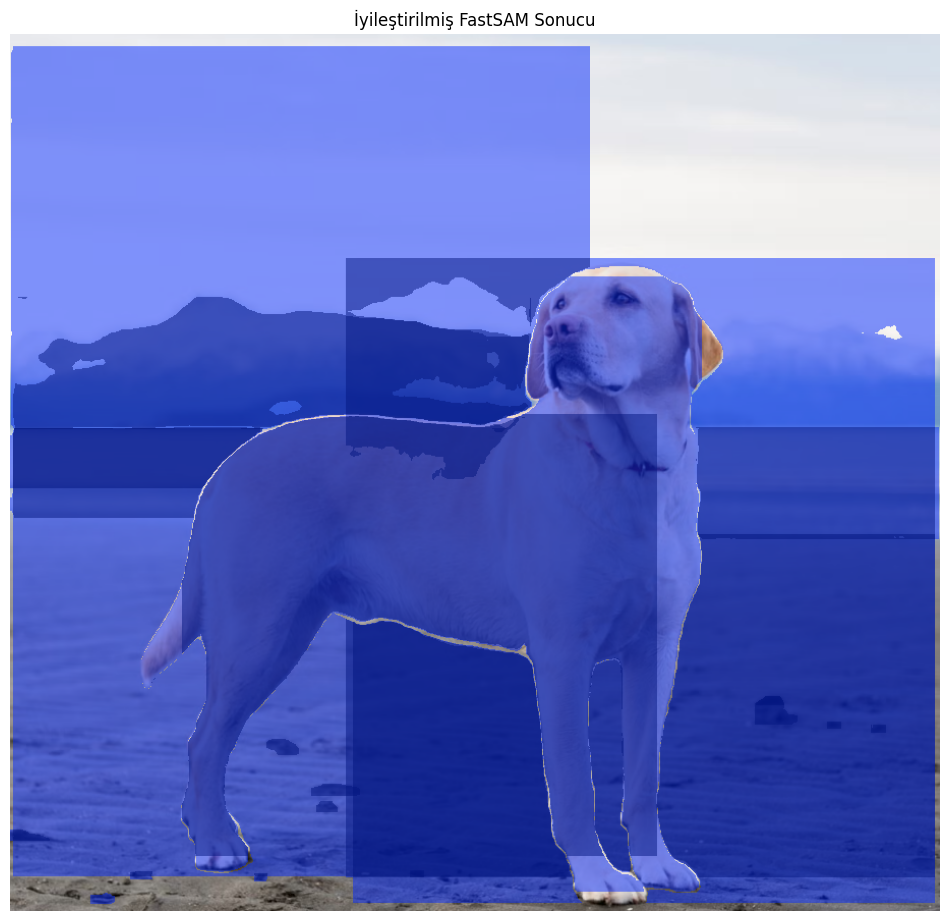

In [9]:
# Parametreleri iyileştirerek tekrar çalıştıralım
# conf: 0.25 gibi daha düşük değerler daha fazla maske yakalar
# iou: 0.7-0.9 arası değerler maske kalitesini etkiler
# imgsz: 1024 çözünürlük detaylar için idealdir

results = model(
    img_path,
    device='cpu',
    retina_masks=True,
    imgsz=1024,
    conf=0.25, # Güven eşiğini düşürerek daha hassas hale getirdik
    iou=0.7    # Örtüşme eşiği
)

# Görselleştirme
res_plotted = results[0].plot(labels=False, boxes=False) # Sadece maskeleri görmek için etiketleri kapattık
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(res_rgb)
plt.axis('off')
plt.title("İyileştirilmiş FastSAM Sonucu")
plt.show()

```markdown
### 5. Adım: Daha İyi Sonuçlar İçin Nokta Belirteci (Point Prompt)

Eğer tüm resim yerine sadece belirli bir nesneyi (örneğin sadece köpeği) seçmek isterseniz, resim üzerinde bir nokta belirleyebilirsiniz. Koordinatlar `[x, y]` formatındadır.
```


image 1/1 /content/Screenshot_2026-06-26_17-03-23.png: 992x1024 23 objects, 1344.1ms
Speed: 7.2ms preprocess, 1344.1ms inference, 117.9ms postprocess per image at shape (1, 3, 992, 1024)


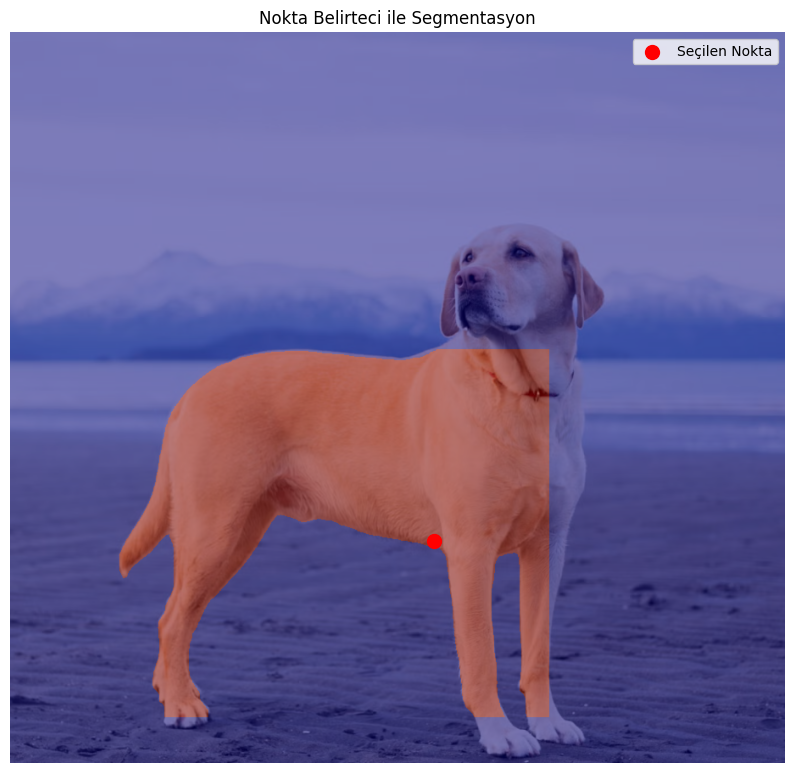

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Modeli tekrar çalıştıralım
results = model(img_path, device='cpu', retina_masks=True, imgsz=1024, conf=0.25)

# FastSAMPrompt kütüphane bağımlılığı olmadan manuel görselleştirme yapalım
# Bu yöntem sürüm farklılıklarından etkilenmez
res = results[0]

# Köpeği hedeflemek için bir nokta (x, y)
# Görselinize göre 500, 600
target_point = (500, 600)

# En uygun maskeyi bulmak için basit bir mantık kuralım:
# Noktayı içeren maskeyi seçelim
found_mask = None
if res.masks is not None:
    for mask in res.masks.data:
        mask_np = mask.cpu().numpy()
        # Maske koordinatları resim boyutuyla eşleşmeli
        h, w = mask_np.shape
        y, x = int(target_point[1] * h / 1024), int(target_point[0] * w / 1024)
        x = min(x, w-1)
        y = min(y, h-1)

        if mask_np[y, x] > 0:
            found_mask = mask_np
            break

if found_mask is not None:
    # Orijinal resmi yükle
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Maskeyi uygula
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.imshow(found_mask, alpha=0.5, cmap='jet') # Maskeyi yarı saydam üst üste bindir
    plt.scatter([target_point[0]], [target_point[1]], color='red', s=100, label='Seçilen Nokta')
    plt.title("Nokta Belirteci ile Segmentasyon")
    plt.legend()
    plt.axis('off')
    plt.show()
else:
    print("Belirtilen noktada bir nesne bulunamadı. Lütfen koordinatları güncelleyin.")